# 01 — Stable Diffusion (img2img)

Generate synthetic chest X-rays using Stable Diffusion's img2img mode.

**Approach:** Feed real X-rays as input, SD generates synthetic variations while preserving structure.

**Note:** FID comparison is exploratory here — img2img has a different input distribution than noise-to-image models.

## Setup

In [1]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

import torchxrayvision as xrv
from diffusers import StableDiffusionImg2ImgPipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
# paths
DATA_DIR = Path("../data")
REAL_PNEUMONIA = DATA_DIR / "pneumonia"
REAL_NORMAL = DATA_DIR / "normal"

OUTPUT_DIR = Path("outputs/01_stable_diffusion")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 64
N_GENERATE = 100

## Dataset Loading

In [3]:
def get_image_paths(folder: Path) -> list:
    extensions = {'.jpeg', '.jpg', '.png'}
    return sorted([
        p for p in folder.iterdir() 
        if p.suffix.lower() in extensions and not p.name.startswith('.')
    ])

real_paths = get_image_paths(REAL_PNEUMONIA)
print(f"Real pneumonia images available: {len(real_paths)}")

# sample 100 images as input for img2img
random.shuffle(real_paths)
input_paths = real_paths[:N_GENERATE]
print(f"Selected {len(input_paths)} images for generation")

Real pneumonia images available: 3875
Selected 100 images for generation


## Model Architecture

Stable Diffusion v1.5 in img2img mode. `strength=0.7` balances structure preservation with variation.

In [4]:
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    safety_checker=None,
    requires_safety_checker=False
)
pipe = pipe.to(device)

# reduce memory usage on limited GPU
if torch.cuda.is_available():
    pipe.enable_attention_slicing()

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /Users/lakshya/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Training

N/A — using pretrained Stable Diffusion. No fine-tuning needed for img2img mode.

## Generate 100 Images

In [5]:
STRENGTH = 0.7
PROMPT = "chest x-ray, medical radiograph, grayscale"
NEGATIVE_PROMPT = "color, artistic, painting, drawing, cartoon"

# SD expects RGB, we'll convert back to grayscale after
SD_SIZE = 512

In [6]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

generated_paths = []

for i, img_path in enumerate(tqdm(input_paths, desc="Generating")):
    # load and prepare input image
    img = Image.open(img_path).convert('L')
    # SD needs RGB and 512x512
    img_rgb = img.convert('RGB').resize((SD_SIZE, SD_SIZE), Image.LANCZOS)
    
    # generate
    with torch.no_grad():
        result = pipe(
            prompt=PROMPT,
            negative_prompt=NEGATIVE_PROMPT,
            image=img_rgb,
            strength=STRENGTH,
            guidance_scale=7.5,
            num_inference_steps=50,
            generator=torch.Generator(device=device).manual_seed(SEED + i)
        )
    
    # convert back to 64x64 grayscale
    gen_img = result.images[0].convert('L').resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    
    # save as PNG
    out_path = generated_dir / f"{i:04d}.png"
    gen_img.save(out_path, 'PNG')
    generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

...

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/35 [00:00<?, ?it/s]

Generating:  19%|█▉        | 19/100 [29:25<2:05:26, 92.92s/it]


KeyboardInterrupt: 

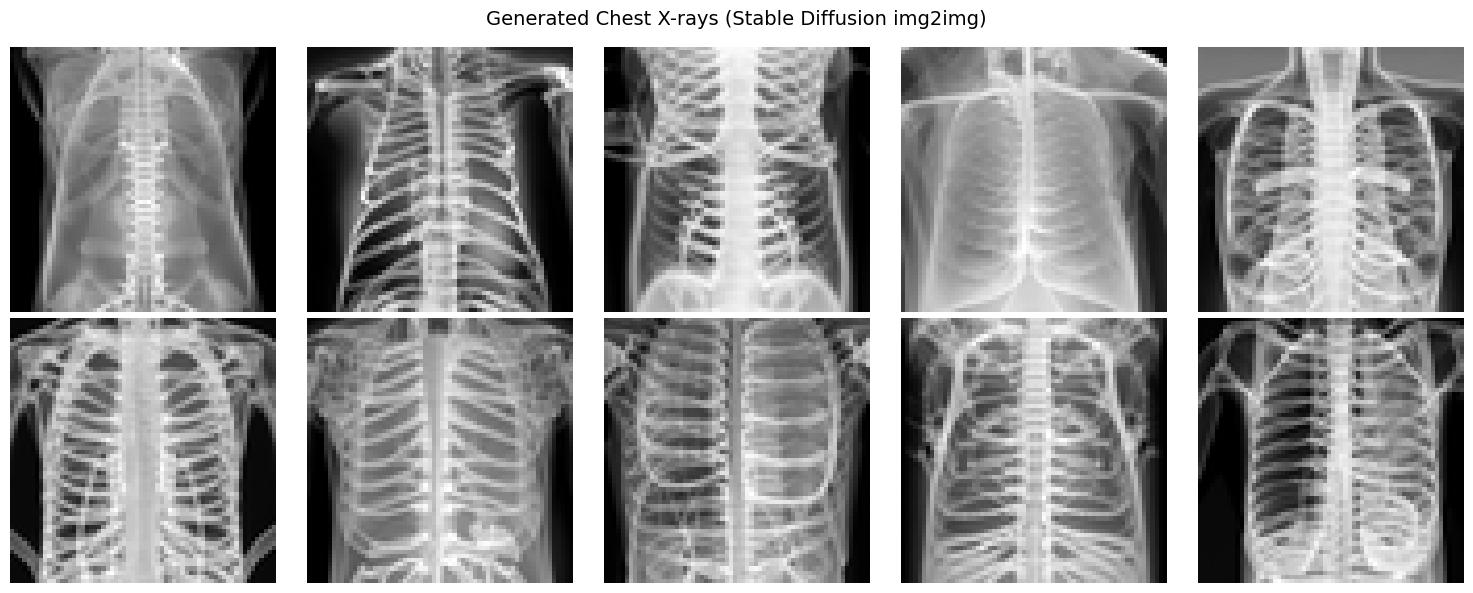

In [7]:
# visualize some generated images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (Stable Diffusion img2img)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

FID computed using torchxrayvision DenseNet121 features instead of Inception V3.
Domain-adapted since DenseNet121 was trained on real chest X-rays.

**Note:** FID comparison is exploratory — img2img uses real images as input, not noise.

In [8]:
# load torchxrayvision model for feature extraction
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

# remove classification head to get features
feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /Users/lakshya/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [9]:
def load_and_preprocess_for_xrv(img_path):
    """Load image and preprocess for torchxrayvision (224x224, normalized)."""
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    # xrv expects [-1024, 1024] range
    img = (img / 255.0) * 2048 - 1024
    # add channel dim
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)

In [10]:
def extract_features(image_paths, batch_size=32):
    """Extract DenseNet121 features from images."""
    features = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        
        with torch.no_grad():
            feat = feature_extractor(batch)
            # global average pooling
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    
    return np.concatenate(features, axis=0)

In [11]:
def compute_fid(real_features, fake_features):
    """Compute FID between two sets of features."""
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    
    diff = mu_real - mu_fake
    
    # compute sqrt of product of covariances
    covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
    
    # handle numerical instability
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    
    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return float(fid)

In [12]:
# sample 100 real images for FID comparison
real_sample = random.sample(real_paths, N_GENERATE)

print("Extracting features from real images...")
real_features = extract_features(real_sample)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:06<00:00,  1.55s/it]


Extracting features from generated images...


Extracting features: 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]



Domain-adapted FID (DenseNet121): 119.02


## Evaluate — Label + TSTR (torchxrayvision)

Label generated images using torchxrayvision's pretrained classifier.
Proxy TSTR: check if medical classifier recognizes synthetic images as valid X-rays.

In [13]:
def label_images(image_paths, batch_size=32):
    """Get torchxrayvision predictions for images."""
    all_predictions = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    
    return np.concatenate(all_predictions, axis=0)

In [14]:
# get labels
predictions = label_images(generated_paths)

# torchxrayvision pathology names
pathology_names = xrv_model.pathologies
print(f"Pathologies: {pathology_names}")

Labeling: 100%|██████████| 1/1 [00:01<00:00,  1.41s/it]

Pathologies: ['Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 'Hernia', 'Lung Lesion', 'Fracture', 'Lung Opacity', 'Enlarged Cardiomediastinum']


In [15]:
# find pneumonia-related pathology index
pneumonia_idx = None
for i, name in enumerate(pathology_names):
    if 'pneumonia' in name.lower() or 'lung opacity' in name.lower():
        pneumonia_idx = i
        print(f"Using pathology '{name}' at index {i}")
        break

if pneumonia_idx is None:
    # fallback to 'Lung Opacity' which is related
    pneumonia_idx = list(pathology_names).index('Lung Opacity')
    print(f"Using 'Lung Opacity' at index {pneumonia_idx}")

Using pathology 'Pneumonia' at index 8


In [16]:
# proxy TSTR: what fraction of generated pneumonia images are classified as having lung opacity
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.001
  Classified as pneumonia (>0.5): 0/19 (0.0%)


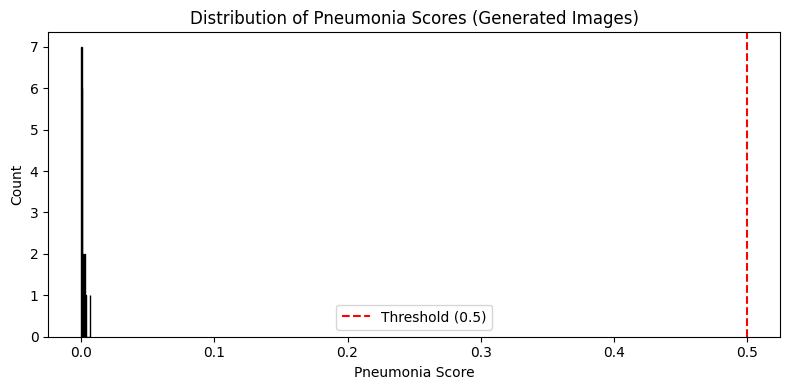

In [17]:
# histogram of pneumonia scores
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (Generated Images)')
plt.legend()
plt.tight_layout()
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [18]:
# create labels dataframe
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

# add all pathology scores
for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

labels_df.head()

Saved labels to outputs/01_stable_diffusion/labels.csv


,filename,pneumonia_score,predicted_label,Atelectasis,Consolidation,Infiltration,Pneumothorax,Edema,Emphysema,Fibrosis,...,Pneumonia,Pleural_Thickening,Cardiomegaly,Nodule,Mass,Hernia,Lung Lesion,Fracture,Lung Opacity,Enlarged Cardiomediastinum
0,0000.png,0.000162,normal,0.174954,0.356758,0.513923,0.505376,0.000444,0.029886,0.363133,...,0.000162,0.502164,0.264592,0.264282,0.502407,0.092279,0.007006,0.231558,0.863803,0.501548
1,0001.png,0.003172,normal,0.135785,0.281934,0.504731,0.556259,0.000016,0.000476,0.001805,...,0.003172,0.001259,0.065583,0.084796,0.503577,0.001888,0.011109,0.011809,0.795595,0.175683
2,0002.png,0.002377,normal,0.517225,0.486702,0.410303,0.548466,0.002439,0.500390,0.143182,...,0.002377,0.043575,0.520785,0.327823,0.512953,0.004774,0.163195,0.515216,0.857648,0.513245
3,0003.png,0.000381,normal,0.180263,0.521755,0.483316,0.515485,0.000946,0.103609,0.243163,...,0.000381,0.501377,0.048827,0.146597,0.221987,0.008192,0.003190,0.139703,0.825783,0.165350
4,0004.png,0.000052,normal,0.408419,0.298269,0.268819,0.555575,0.000231,0.017184,0.032477,...,0.000052,0.036740,0.444495,0.360097,0.526589,0.006562,0.016650,0.336519,0.902367,0.260740


In [19]:
# save metrics
metrics = {
    'model': 'stable_diffusion_img2img',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'strength': STRENGTH,
    'seed': SEED,
    'note': 'FID comparison exploratory — different input distribution'
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/01_stable_diffusion/metrics.json
{
  "model": "stable_diffusion_img2img",
  "n_generated": 19,
  "fid_domain_adapted": 119.01939138739242,
  "tstr_accuracy": 0.0,
  "mean_pneumonia_score": 0.0010548837017267942,
  "strength": 0.7,
  "seed": 42,
  "note": "FID comparison exploratory \u2014 different input distribution"
}


## Results

**Summary:**

In [20]:
print("="*50)
print("STABLE DIFFUSION (img2img) RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print("="*50)
print(f"Outputs saved to: {OUTPUT_DIR}")
print(f"  - images/: {len(generated_paths)} PNG files")
print(f"  - labels.csv")
print(f"  - metrics.json")

STABLE DIFFUSION (img2img) RESULTS
Images generated: 19
Domain-adapted FID: 119.02
Proxy TSTR accuracy: 0.0%
Mean pneumonia score: 0.001
Outputs saved to: outputs/01_stable_diffusion
  - images/: 19 PNG files
  - labels.csv
  - metrics.json
